# 1) Clasificación binaria (Imágenes): HotDog vs NotHotDog

Objetivo: entrenar un clasificador binario que distinga entre imágenes de hot-dog y no-hot-dog.

En este caso trabajaremos con imágenes, por lo que el modelo adecuado es una **Red Neuronal Convolucional (CNN)**.  
Compararemos:

- **Modelo base (sin tuning)**: CNN simple con hiperparámetros fijos.
- **Modelo optimizado (con tuning)**: búsqueda aleatoria (Random Search) sobre hiperparámetros relevantes.

Métricas de evaluación (antes vs después):
- Accuracy
- Precision, Recall, F1
- ROC-AUC
- Matriz de confusión (visual)

Conclusión esperada: el tuning debe mejorar (o al menos justificar cambios en) el rendimiento y/o la capacidad de generalización del modelo.

## Sección 0 — Instalación de dependencias

Qué hacemos aquí:
- Instalamos librerías necesarias para:
  - Descargar el dataset desde Kaggle con `kagglehub`.
  - Entrenar CNNs con TensorFlow.
  - Hacer tuning con `RandomizedSearchCV` usando el wrapper `SciKeras`.

Qué obtenemos:
- El entorno de Colab listo para ejecutar el pipeline completo (carga → entrenamiento → tuning → evaluación).

In [19]:
!pip -q install scikeras scikit-learn kagglehub tensorflow


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
!pip install numpy tensorflow matplotlib opencv-python scikit-learn scikeras kagglehub pandas


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [25]:
!pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Sección 1 — Imports y configuración de reproducibilidad

Qué hacemos aquí:
- Importamos librerías de:
  - Manipulación de datos (NumPy).
  - Entrenamiento del modelo (TensorFlow).
  - Lectura/redimensionamiento de imágenes (OpenCV).
  - Métricas y validación (scikit-learn).
- Configuramos una semilla (`SEED`) para que:
  - Splits de train/val/test sean reproducibles.
  - Resultados del entrenamiento sean lo más comparables posible.

Cambio clave vs un notebook “rápido”:
- Sin semillas, el “antes vs después” puede ser injusto: a veces el modelo mejora o empeora solo por azar.

Qué obtenemos:
- Un entorno estable para comparar el modelo base y el tuned.

In [9]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from glob import glob
import cv2

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

from scikeras.wrappers import KerasClassifier
import kagglehub

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 64

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sección 2 — Descarga y carga del dataset (HotDog vs NotHotDog)

Qué hacemos aquí:
- Descargamos el dataset con `kagglehub`.
- Detectamos si viene con estructura típica:
  - `train/` y `test/` (con subcarpetas por clase).
- Si no existe esa estructura, hacemos un split manual 80/20.

Decisiones importantes:
- Leemos imágenes desde disco, las convertimos a RGB, y las redimensionamos a `IMG_SIZE x IMG_SIZE`.
- Mantenemos el dataset en memoria como:
  - `X`: arreglo de imágenes (H, W, 3)
  - `y`: etiquetas 0/1

Qué obtenemos:
- `X_train_raw`, `y_train`, `X_test_raw`, `y_test`
- `class_names`: nombres reales de carpetas detectadas (útil para validar cuál clase quedó como 0/1).

In [10]:
def _list_image_files(folder):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
    files = []
    for ext in exts:
        files.extend(glob(os.path.join(folder, "**", ext), recursive=True))
    return sorted(files)

def _load_split(base_dir, img_size=64, max_per_class=None):
    if not os.path.isdir(base_dir):
        raise FileNotFoundError(f"No existe el directorio: {base_dir}")

    class_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    if len(class_dirs) < 2:
        raise ValueError(f"Esperaba 2+ carpetas de clases dentro de {base_dir}, encontré: {class_dirs}")

    class_dirs_sorted = sorted(class_dirs)

    neg_candidates = [d for d in class_dirs_sorted if any(k in d.lower() for k in ["not", "non", "negative"])]
    if len(neg_candidates) >= 1:
        neg_dir = neg_candidates[0]
        pos_dir = [d for d in class_dirs_sorted if d != neg_dir][0]
    else:
        neg_dir, pos_dir = class_dirs_sorted[:2]

    def read_images_from_dir(dir_name, label):
        folder = os.path.join(base_dir, dir_name)
        paths = _list_image_files(folder)
        if max_per_class is not None:
            paths = paths[:max_per_class]

        X_list, y_list = [], []
        for p in paths:
            img = cv2.imread(p)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
            X_list.append(img)
            y_list.append(label)

        return np.array(X_list, dtype=np.uint8), np.array(y_list, dtype=np.int64)

    X_neg, y_neg = read_images_from_dir(neg_dir, 0)
    X_pos, y_pos = read_images_from_dir(pos_dir, 1)

    X = np.concatenate([X_neg, X_pos], axis=0)
    y = np.concatenate([y_neg, y_pos], axis=0)

    perm = np.random.permutation(len(y))
    X = X[perm]
    y = y[perm]

    return X, y, [neg_dir, pos_dir]

def load_hotdog_dataset(img_size=64):
    path = kagglehub.dataset_download("dansbecker/hot-dog-not-hot-dog")
    print("Dataset descargado en:", path)

    train_dir = os.path.join(path, "train")
    test_dir = os.path.join(path, "test")

    if os.path.isdir(train_dir) and os.path.isdir(test_dir):
        X_train, y_train, class_names = _load_split(train_dir, img_size=img_size)
        X_test, y_test, _ = _load_split(test_dir, img_size=img_size)
    else:
        X_all, y_all, class_names = _load_split(path, img_size=img_size)
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
        )

    return X_train, y_train, X_test, y_test, class_names

X_train_raw, y_train, X_test_raw, y_test, class_names = load_hotdog_dataset(img_size=IMG_SIZE)
print("Clases:", class_names)
print("Train:", X_train_raw.shape, "Test:", X_test_raw.shape)

100%|██████████| 89.3M/89.3M [00:02<00:00, 32.6MB/s]

Extracting files...


Dataset descargado en: /Users/juandaniel/.cache/kagglehub/datasets/dansbecker/hot-dog-not-hot-dog/versions/5
Clases: ['not_hot_dog', 'hot_dog']
Train: (498, 64, 64, 3) Test: (500, 64, 64, 3)


## Sección 3 — Visualización rápida (sanity check)

Qué hacemos aquí:
- Mostramos ejemplos aleatorios del set de entrenamiento.
- Confirmamos:
  - Que efectivamente son imágenes válidas.
  - Que el redimensionamiento se aplicó bien.
  - Que las etiquetas (0/1) se ven coherentes con el contenido.

Qué obtenemos:
- Una validación rápida para detectar errores típicos:
  - Imágenes corruptas.
  - Canales invertidos (BGR vs RGB).
  - Etiquetas intercambiadas.

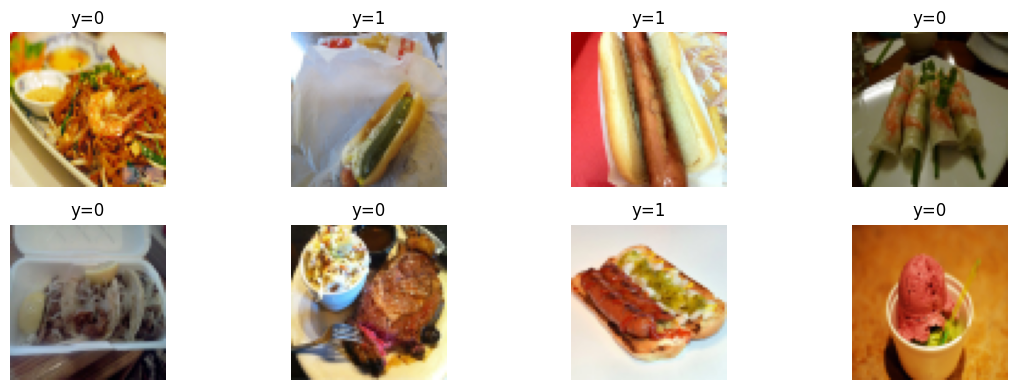

In [11]:
def show_samples(X, y, n=8):
    idx = np.random.choice(len(y), size=n, replace=False)
    plt.figure(figsize=(12, 4))
    for i, j in enumerate(idx, 1):
        plt.subplot(2, n//2, i)
        plt.imshow(X[j])
        plt.title(f"y={y[j]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(X_train_raw, y_train, n=8)

## Sección 4 — Preprocesamiento y split de validación

Qué hacemos aquí:
- Convertimos las imágenes de enteros (0–255) a flotantes (0–1):
  - Esto estabiliza el entrenamiento (gradientes más razonables).
- Creamos un split de validación desde el train:
  - `train` para entrenar pesos.
  - `val` para monitorear generalización y aplicar early stopping.

Cambio clave:
- Tener un conjunto `val` separado permite:
  - Detener el entrenamiento cuando deja de mejorar.
  - Evitar “overfitting” silencioso.

Qué obtenemos:
- `X_tr`, `y_tr` (entrenamiento)
- `X_val`, `y_val` (validación)
- `X_test`, `y_test` (prueba final, intocable durante entrenamiento/tuning)

In [12]:
X_train = X_train_raw.astype("float32") / 255.0
X_test  = X_test_raw.astype("float32") / 255.0

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print("Train split:", X_tr.shape, "Val split:", X_val.shape)

Train split: (398, 64, 64, 3) Val split: (100, 64, 64, 3)


## Sección 5 — Modelo base (CNN simple, sin tuning)

Qué hacemos aquí:
- Definimos una CNN “razonable” como baseline:
  - 3 bloques conv + maxpool (extracción jerárquica de features).
  - `Dropout` para regularización.
  - Capa final `sigmoid` para probabilidad binaria.
- Entrenamos con hiperparámetros fijos:
  - `n_filters=32`, `dropout=0.3`, `learning_rate=1e-3`
- Usamos `EarlyStopping` sobre `val_loss`:
  - Evita sobreentrenar y recupera los mejores pesos.

Qué obtenemos:
- `base_model`: el modelo base entrenado.
- `history_base`: trazas de entrenamiento/validación para análisis.

Interpretación esperada:
- Este modelo ya debería ser decente, pero no necesariamente óptimo.
- Es el “punto de referencia” para medir el impacto del tuning.

In [13]:
def build_cnn_model(
    n_filters=32,
    dropout=0.3,
    learning_rate=1e-3
):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        tf.keras.layers.Conv2D(n_filters, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(n_filters*2, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(n_filters*4, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

base_model = build_cnn_model(n_filters=32, dropout=0.3, learning_rate=1e-3)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_base = base_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5151 - loss: 0.7018 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 2/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5528 - loss: 0.6898 - val_accuracy: 0.6000 - val_loss: 0.6848
Epoch 3/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5553 - loss: 0.6882 - val_accuracy: 0.6300 - val_loss: 0.6796
Epoch 4/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6106 - loss: 0.6674 - val_accuracy: 0.6100 - val_loss: 0.6400
Epoch 5/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6030 - loss: 0.6627 - val_accuracy: 0.5500 - val_loss: 0.6735
Epoch 6/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6734 - loss: 0.6177 - val_accuracy: 0.6400 - val_loss: 0.6304
Epoch 7/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6884 - loss: 0.5964 - val_accuracy: 0.5800 - val_loss: 0.6560
Epoch 8/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7663 - loss: 0.5227 - val_accuracy: 0.6200 - v

## Sección 6 — Evaluación del modelo base (métricas + visualizaciones)

Qué hacemos aquí:
- Generamos probabilidades (`y_prob_base`) y predicciones binarias (`y_pred_base`) sobre el **test**.
- Calculamos métricas:
  - Accuracy: desempeño global.
  - Precision/Recall/F1: calidad de clasificación (útil si hay sesgo hacia una clase).
  - ROC-AUC: mide separabilidad general (basada en probabilidades, no solo umbral 0.5).
- Visualizamos:
  - Matriz de confusión: errores por tipo (FP/FN).
  - Curva ROC: trade-off TPR vs FPR.

Qué obtenemos:
- Un “reporte base” completo para comparar contra el tuned.
- Visualizaciones que le dan credibilidad al análisis, no solo un número.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
=== MODELO BASE ===
Accuracy : 0.5760
Precision: 0.6011
Recall   : 0.4520
F1       : 0.5160
ROC-AUC  : 0.5812


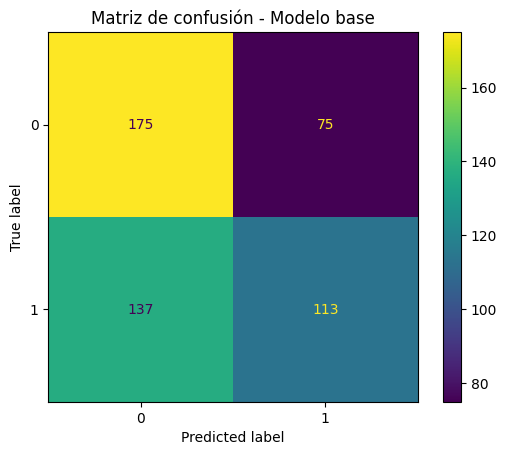

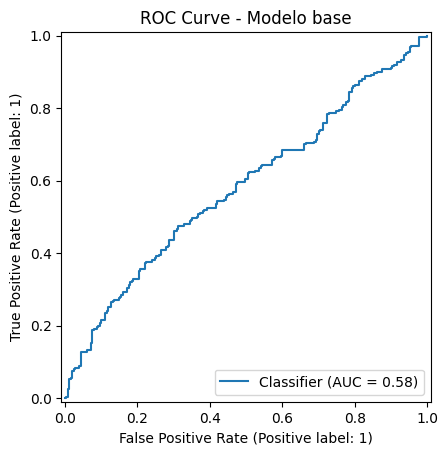

In [14]:
y_prob_base = base_model.predict(X_test).ravel()
y_pred_base = (y_prob_base >= 0.5).astype(int)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)
auc_base = roc_auc_score(y_test, y_prob_base)

print("=== MODELO BASE ===")
print(f"Accuracy : {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall   : {rec_base:.4f}")
print(f"F1       : {f1_base:.4f}")
print(f"ROC-AUC  : {auc_base:.4f}")

cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Matriz de confusión - Modelo base")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_base)
plt.title("ROC Curve - Modelo base")
plt.show()

## Sección 7 — Tuning de hiperparámetros (RandomizedSearchCV + SciKeras)

Qué hacemos aquí:
- Envolvemos el modelo de TensorFlow dentro de un estimador compatible con scikit-learn (`KerasClassifier`).
- Definimos un espacio de hiperparámetros realmente relevantes para CNN:
  - `n_filters`: capacidad del extractor (más filtros = más capacidad).
  - `dropout`: regularización para mejorar generalización.
  - `learning_rate`: controla la estabilidad y velocidad de aprendizaje.
  - `batch_size` y `epochs`: dinámica de entrenamiento.
- Ejecutamos `RandomizedSearchCV`:
  - Busca combinaciones al azar en el espacio definido.
  - Es más eficiente que GridSearch cuando hay varios hiperparámetros.

Por qué Random Search aquí:
- En deep learning, el espacio es grande y GridSearch se vuelve costoso.
- RandomSearch suele encontrar buenas zonas con menos evaluaciones.

Qué obtenemos:
- `best_params_`: combinación recomendada.
- `best_score_`: desempeño estimado por validación cruzada (CV) usando la métrica objetivo.

Nota para tu análisis:
- Usamos `scoring="f1"` para priorizar equilibrio entre precision y recall (mejor argumento académico que solo accuracy).

In [15]:
def make_sci_model(n_filters=32, dropout=0.3, learning_rate=1e-3):
    return build_cnn_model(n_filters=n_filters, dropout=dropout, learning_rate=learning_rate)

clf = KerasClassifier(
    model=make_sci_model,
    epochs=12,
    batch_size=32,
    verbose=0
)

param_dist = {
    "model__n_filters": [16, 32, 48, 64],
    "model__dropout": [0.2, 0.3, 0.4, 0.5],
    "model__learning_rate": [1e-4, 3e-4, 1e-3, 3e-3],
    "batch_size": [16, 32, 64],
    "epochs": [8, 12, 16],
}

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=SEED,
    n_jobs=-1
)

print("Ejecutando RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor score CV (F1):", random_search.best_score_)

Ejecutando RandomizedSearchCV...


Mejores hiperparámetros: {'model__n_filters': 48, 'model__learning_rate': 0.0003, 'model__dropout': 0.5, 'epochs': 12, 'batch_size': 16}
Mejor score CV (F1): 0.6923610789772322


## Sección 8 — Evaluación del mejor modelo (tuned)

Qué hacemos aquí:
- Tomamos el mejor estimador encontrado por el tuning (`best_estimator_`).
- Evaluamos en el mismo conjunto de prueba (test) para comparar justo contra el modelo base.
- Recalculamos las mismas métricas y las mismas visualizaciones:
  - Si cambias métricas, la comparación se vuelve inválida.

Qué obtenemos:
- Un “reporte tuned” comparable con el “reporte base”.

Cómo interpretar resultados:
- Si sube F1 y ROC-AUC: tuning mejoró generalización/separación.
- Si sube accuracy pero baja F1: posible sesgo hacia una clase (ojo).
- Si no mejora: el baseline ya estaba cerca del óptimo o el search no exploró suficiente (o dataset limitado).

=== MODELO TUNED ===
Accuracy : 0.5980
Precision: 0.5891
Recall   : 0.6480
F1       : 0.6171
ROC-AUC  : 0.6360


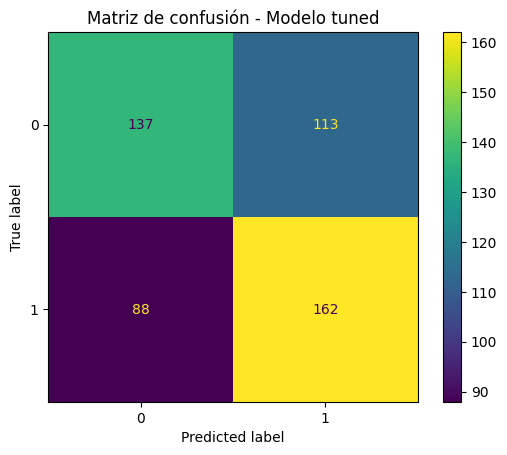

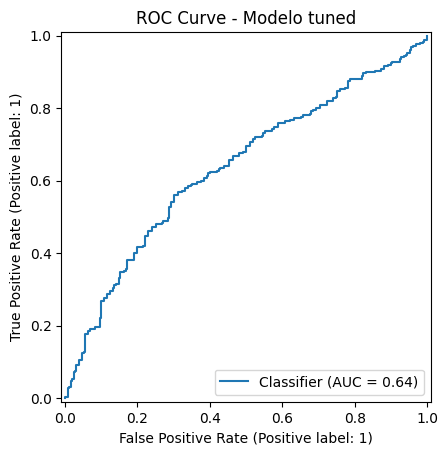

In [16]:
best_clf = random_search.best_estimator_
y_prob_tuned = best_clf.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_prob_tuned >= 0.5).astype(int)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
rec_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("=== MODELO TUNED ===")
print(f"Accuracy : {acc_tuned:.4f}")
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall   : {rec_tuned:.4f}")
print(f"F1       : {f1_tuned:.4f}")
print(f"ROC-AUC  : {auc_tuned:.4f}")

cm2 = confusion_matrix(y_test, y_pred_tuned)
disp2 = ConfusionMatrixDisplay(cm2)
disp2.plot()
plt.title("Matriz de confusión - Modelo tuned")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_tuned)
plt.title("ROC Curve - Modelo tuned")
plt.show()

## Sección 9 — Comparación final (tabla antes vs después)

Qué hacemos aquí:
- Consolidamos en una tabla las métricas del modelo base y el tuned.
- Esta tabla es la pieza clave para “Comparar antes y después” como pide la tarea.

Qué obtenemos:
- Un resumen numérico para:
  - Reportarlo en el entregable.
  - Construir conclusiones basadas en evidencia.

In [21]:
import pandas as pd

df_compare = pd.DataFrame([
    {"Modelo": "Base",  "Accuracy": acc_base,  "Precision": prec_base,  "Recall": rec_base,  "F1": f1_base,  "ROC-AUC": auc_base},
    {"Modelo": "Tuned", "Accuracy": acc_tuned, "Precision": prec_tuned, "Recall": rec_tuned, "F1": f1_tuned, "ROC-AUC": auc_tuned},
])

df_compare

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Base,0.576,0.601064,0.452,0.515982,0.581168
1,Tuned,0.598,0.589091,0.648,0.617143,0.636016


## Sección 10 — Conclusiones (plantilla para llenar con tus resultados)

Qué debes escribir aquí (concretamente):
1) **Qué cambió con el tuning**: reporta los mejores hiperparámetros.
2) **Impacto cuantitativo**: menciona cambios en F1 y ROC-AUC (y accuracy si aplica).
3) **Interpretación**:
   - Si mejoró: explica por qué (mayor capacidad, mejor LR, mejor regularización).
   - Si no mejoró: explica hipótesis realistas (baseline fuerte, poca data, search limitado).
4) **Recomendación técnica** (1–2 líneas):
   - Data augmentation, aumentar IMG_SIZE, más iteraciones del search, o ajustar rango de LR.

Ejemplo de redacción (solo estructura, tú pegas números reales):
- “El tuning incrementó F1 de X a Y y ROC-AUC de A a B, lo que sugiere una mejor separabilidad y equilibrio entre errores…”
- “El mejor modelo usó n_filters=…, dropout=…, learning_rate=…, indicando que…”

# 2) Clasificación multiclase (tabular): Dry Bean Dataset (7 clases)

Objetivo: entrenar un modelo de **clasificación multiclase** para predecir el tipo de fríjol (bean) a partir de características numéricas extraídas de imágenes (área, perímetro, forma, etc.).

Estrategia (igual que en binaria):
1) Entrenar un **modelo base** (sin tuning).
2) Realizar **optimización de hiperparámetros** (tuning).
3) Comparar **antes vs después** con métricas apropiadas para multiclase.
4) Analizar el impacto del tuning y concluir.

Por qué este dataset es buena elección:
- Multiclase real (7 categorías).
- Tabular, con features numéricas informativas.
- Tamaño suficiente para que el tuning sí genere diferencias medibles.

## Sección 1 — Imports y reproducibilidad

Qué hacemos:
- Importamos librerías de análisis (pandas, numpy), modelado (sklearn) y visualización (matplotlib).
- Definimos `SEED` para que:
  - el split train/test sea reproducible,
  - la comparación base vs tuned sea justa.

Qué obtenemos:
- Un setup consistente para todo el experimento.

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)

## Sección 2 — Descarga y carga del Dry Bean Dataset

Qué hacemos:
- Descargamos el dataset de Kaggle usando `kagglehub`.
- Buscamos el archivo CSV dentro de la carpeta descargada.
- Cargamos el CSV con pandas.

Qué obtenemos:
- `df`: DataFrame con columnas numéricas (features) y la columna objetivo (clase del fríjol).
- Un vistazo inicial (shape, columnas, valores faltantes) para saber con qué trabajamos.

In [28]:
# Descarga del dataset (Kaggle)
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")
print("Dataset descargado en:", path)

# Buscar archivo Excel dentro del directorio
xlsx_files = []
for root, _, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".xlsx") or f.lower().endswith(".xls"):
            xlsx_files.append(os.path.join(root, f))

if len(xlsx_files) == 0:
    raise FileNotFoundError("No encontré ningún archivo Excel en el dataset descargado. Revisa la estructura del dataset.")

xlsx_path = xlsx_files[0]
print("Archivo encontrado:", xlsx_path)

# Leer el Excel (toma la primera hoja por defecto)
df = pd.read_excel(xlsx_path, sheet_name=0)
df.head()



Dataset descargado en: /Users/juandaniel/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1
Archivo encontrado: /Users/juandaniel/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [29]:
print("Shape:", df.shape)
print("\nColumnas:\n", df.columns)
print("\nNulos por columna (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))

Shape: (13611, 17)

Columnas:
 Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

Nulos por columna (top 10):
 Area            0
Solidity        0
ShapeFactor4    0
ShapeFactor3    0
ShapeFactor2    0
ShapeFactor1    0
Compactness     0
roundness       0
Extent          0
Perimeter       0
dtype: int64


## Sección 3 — Definición de target (y) y features (X)

Qué hacemos:
- Identificamos la columna objetivo (clase).
  - En este dataset típicamente se llama `Class`.
- Separamos:
  - `X`: features (variables predictoras)
  - `y`: target multiclase (categoría)

Qué obtenemos:
- Variables listas para:
  - split train/test,
  - pipeline de preprocesamiento,
  - entrenamiento del modelo.

In [30]:
# Detectar columna objetivo
target_candidates = [c for c in df.columns if c.lower() in ["class", "label", "target", "y"]]
if len(target_candidates) == 0:
    # fallback: si no se detecta, asumimos que la última columna es el target
    target_col = df.columns[-1]
else:
    target_col = target_candidates[0]

print("Columna objetivo detectada:", target_col)

X = df.drop(columns=[target_col])
y = df[target_col].astype(str)  # aseguramos que sea categórica

print("Clases:", sorted(y.unique()))
print("Distribución de clases:\n", y.value_counts())

Columna objetivo detectada: Class
Clases: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Distribución de clases:
 Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


## Sección 4 — Train/Test split (estratificado)

Qué hacemos:
- Separamos el dataset en:
  - train (80%)
  - test (20%)
- Usamos `stratify=y` para conservar proporciones de clases en ambos conjuntos.

Por qué es importante en multiclase:
- Si una clase queda sub-representada en test, las métricas se vuelven inestables o engañosas.

Qué obtenemos:
- Conjunto de prueba confiable para comparar base vs tuned.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (10888, 16) Test: (2723, 16)


## Sección 5 — Pipeline de preprocesamiento + modelo base (sin tuning)

Qué hacemos:
- Construimos un pipeline estándar:
  - Imputación (por si hay nulos)
  - Escalado (StandardScaler) para modelos sensibles a escala
- Elegimos un **modelo base** apropiado para multiclase:
  - `LogisticRegression` con estrategia multinomial.

Por qué Logistic Regression como baseline:
- Es fuerte, rápido, interpretable y normalmente da un buen punto de partida.
- Permite que el tuning posterior (con un modelo más flexible) muestre mejoras claras.

Qué obtenemos:
- Un baseline reproducible y bien “limpio” que sirve como referencia oficial.

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

base_clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",       
    random_state=SEED
)

base_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", base_clf)
])

base_pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Sección 6 — Entrenamiento y evaluación del modelo base

Qué hacemos:
- Entrenamos el pipeline base con el train.
- Evaluamos en test con métricas multiclase:
  - Accuracy (visión general)
  - F1 macro (promedia clases por igual; evita que una clase dominante “mande”)
- Generamos:
  - `classification_report` (precision/recall/F1 por clase)
  - Matriz de confusión (qué clases se confunden entre sí)

Qué obtenemos:
- El rendimiento “antes de tuning” documentado y visual.

=== MODELO BASE (Logistic Regression) ===
Accuracy  : 0.9214
F1 (macro): 0.9335

Reporte por clase:

              precision    recall  f1-score   support

    BARBUNYA     0.9516    0.8906    0.9201       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9303    0.9417    0.9360       326
    DERMASON     0.9240    0.9083    0.9161       709
       HOROZ     0.9633    0.9508    0.9570       386
       SEKER     0.9303    0.9532    0.9416       406
        SIRA     0.8483    0.8805    0.8641       527

    accuracy                         0.9214      2723
   macro avg     0.9354    0.9321    0.9335      2723
weighted avg     0.9222    0.9214    0.9216      2723



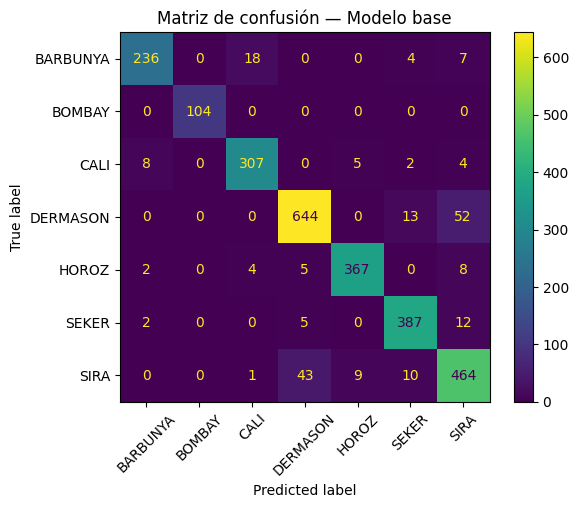

In [34]:
base_pipe.fit(X_train, y_train)

y_pred_base = base_pipe.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_macro_base = f1_score(y_test, y_pred_base, average="macro")

print("=== MODELO BASE (Logistic Regression) ===")
print(f"Accuracy  : {acc_base:.4f}")
print(f"F1 (macro): {f1_macro_base:.4f}\n")

print("Reporte por clase:\n")
print(classification_report(y_test, y_pred_base, digits=4))

cm_base = confusion_matrix(y_test, y_pred_base, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(cm_base, display_labels=sorted(y.unique()))
disp.plot(xticks_rotation=45)
plt.title("Matriz de confusión — Modelo base")
plt.show()

## Sección 7 — Modelo optimizado (tuning) con RandomForestClassifier

Qué hacemos:
- Para el tuning usamos un modelo más flexible:
  - `RandomForestClassifier`, que captura no-linealidades y combinaciones de features.
- Definimos un espacio de hiperparámetros con impacto real:
  - `n_estimators`: cantidad de árboles.
  - `max_depth`: profundidad (controla sobreajuste).
  - `min_samples_split` y `min_samples_leaf`: regularización estructural.
  - `max_features`: cuántas variables considerar por split.

Por qué RandomForest para tuning en esta tarea:
- Es robusto, relativamente rápido, y el tuning suele mejorar con claridad.
- Tiene hiperparámetros fáciles de interpretar en conclusiones.

Qué obtenemos:
- Un `best_estimator_` optimizado según una métrica multiclase.
- Un resultado comparable de forma justa contra el baseline.

In [35]:
rf_clf = RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf_clf)
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=20,                 # puedes bajar a 10 si necesitas que corra más rápido
    scoring="f1_macro",        # métrica recomendada para multiclase
    cv=3,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Ejecutando RandomizedSearchCV para RandomForest...")
search.fit(X_train, y_train)

print("\nMejores hiperparámetros:")
print(search.best_params_)
print("Mejor score CV (F1 macro):", search.best_score_)

Ejecutando RandomizedSearchCV para RandomForest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros:
{'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': None}
Mejor score CV (F1 macro): 0.93558813546609


## Sección 8 — Evaluación del mejor modelo tuned (comparación justa)

Qué hacemos:
- Evaluamos el mejor modelo del tuning en el mismo `X_test`.
- Calculamos exactamente las mismas métricas:
  - Accuracy
  - F1 macro
- Generamos:
  - classification report
  - matriz de confusión

Qué obtenemos:
- El rendimiento “después del tuning”.
- Evidencia para analizar qué mejoró y dónde (en qué clases disminuyeron los errores).

=== MODELO TUNED (RandomForest + RandomSearch) ===
Accuracy  : 0.9192
F1 (macro): 0.9315

Reporte por clase:

              precision    recall  f1-score   support

    BARBUNYA     0.9297    0.8981    0.9136       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9354    0.9325    0.9339       326
    DERMASON     0.9044    0.9210    0.9126       709
       HOROZ     0.9659    0.9534    0.9596       386
       SEKER     0.9349    0.9557    0.9452       406
        SIRA     0.8615    0.8501    0.8558       527

    accuracy                         0.9192      2723
   macro avg     0.9331    0.9301    0.9315      2723
weighted avg     0.9192    0.9192    0.9191      2723



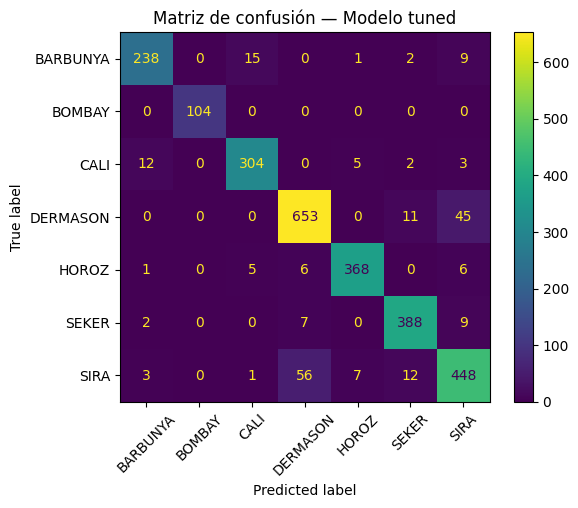

In [36]:
best_pipe = search.best_estimator_

y_pred_tuned = best_pipe.predict(X_test)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_macro_tuned = f1_score(y_test, y_pred_tuned, average="macro")

print("=== MODELO TUNED (RandomForest + RandomSearch) ===")
print(f"Accuracy  : {acc_tuned:.4f}")
print(f"F1 (macro): {f1_macro_tuned:.4f}\n")

print("Reporte por clase:\n")
print(classification_report(y_test, y_pred_tuned, digits=4))

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=sorted(y.unique()))
disp2 = ConfusionMatrixDisplay(cm_tuned, display_labels=sorted(y.unique()))
disp2.plot(xticks_rotation=45)
plt.title("Matriz de confusión — Modelo tuned")
plt.show()

## Sección 9 — Comparación final (tabla antes vs después)

Qué hacemos:
- Consolidamos las métricas principales en una tabla.
- Esto se usa directamente en tu entregable para el requisito:
  “Comparar el desempeño antes y después del ajuste”.

Qué obtenemos:
- Resumen numérico listo para conclusiones.

In [37]:
df_compare_mc = pd.DataFrame([
    {"Modelo": "Base (LogReg multinomial)", "Accuracy": acc_base, "F1_macro": f1_macro_base},
    {"Modelo": "Tuned (RandomForest)",      "Accuracy": acc_tuned, "F1_macro": f1_macro_tuned},
])

df_compare_mc

,Modelo,Accuracy,F1_macro
0,Base (LogReg multinomial),0.921410,0.933538
1,Tuned (RandomForest),0.919207,0.931539


## Sección 10 — Conclusiones (plantilla lista para llenar)

Qué debes escribir (en 6–10 líneas, con tus números reales):

1) **Resultado cuantitativo**:
   - “El tuning mejoró F1 macro de ___ a ___ y accuracy de ___ a ___”.
2) **Interpretación multiclase**:
   - Explica si la mejora fue general o solo en algunas clases.
   - Usa la matriz de confusión como evidencia (“se redujo la confusión entre clase A y B”).
3) **Hiperparámetros clave**:
   - Menciona cuáles quedaron como “mejores” (ej. mayor `n_estimators`, profundidad limitada, etc.).
   - Interpreta por qué ayudan (más árboles = menor varianza; menor profundidad = menos overfitting).
4) **Aprendizaje del experimento**:
   - Conecta con la idea de tuning: “El modelo base es rápido y estable, pero el tuning permitió capturar no-linealidades y balancear mejor el rendimiento por clase”.

# 3) Predicción numérica (Regresión tabular): House Prices (Ames Housing)

Objetivo: entrenar un modelo de **regresión** para predecir un valor numérico: el precio de una casa (`SalePrice`) usando variables tabulares (numéricas y categóricas).

Estrategia (igual que en los otros 2 casos):
1) Entrenar un **modelo base** (sin tuning).
2) Aplicar **optimización de hiperparámetros** (tuning).
3) Comparar **antes vs después** con métricas apropiadas de regresión.
4) Analizar y concluir el impacto del tuning.

Métricas recomendadas:
- **RMSE** (Root Mean Squared Error): penaliza errores grandes.
- **MAE** (Mean Absolute Error): error promedio absoluto, más interpretable.
- (Opcional) **R²**: proporción de varianza explicada.

Nota importante del dataset:
- Este dataset incluye muchas variables categóricas (requiere One-Hot Encoding) y valores faltantes (requiere imputación).

## Sección 1 — Imports y reproducibilidad

Qué hacemos:
- Importamos librerías para:
  - manejo de datos (pandas, numpy),
  - preprocesamiento y modelos (sklearn),
  - visualización (matplotlib).
- Fijamos semilla para reproducibilidad.

Qué obtenemos:
- Un flujo consistente para comparar “antes vs después” sin ruido aleatorio.

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)

## Sección 2 — Descarga y carga del dataset (House Prices)

Qué hacemos:
- Descargamos el dataset “House Prices: Advanced Regression Techniques” desde Kaggle.
- Localizamos el archivo `train.csv` (incluye la variable objetivo `SalePrice`).

Qué obtenemos:
- `df`: DataFrame con features + target.
- Una revisión rápida para confirmar columnas y tamaño.

In [48]:
import os

# Ruta a los archivos descargados manualmente
project_path = "/Users/juandaniel/Projects/Taller 2 - Juan Daniel Torres - Santiago Velazques"
train_csv = os.path.join(project_path, "train.csv")
test_csv  = os.path.join(project_path, "test.csv")

print("✅ train.csv:", train_csv)
df = pd.read_csv(train_csv)
print(f"   Shape: {df.shape}")
df.head()


✅ train.csv: /Users/juandaniel/Projects/Taller 2 - Juan Daniel Torres - Santiago Velazques/train.csv
   Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Sección 3 — Definir target (y) y features (X)

Qué hacemos:
- Definimos `SalePrice` como target numérico.
- Separamos:
  - `X`: todas las columnas excepto `SalePrice`
  - `y`: `SalePrice`

Decisión clave:
- Eliminamos la columna `Id` si existe, porque es un identificador y no aporta señal predictiva.

Qué obtenemos:
- Variables listas para split y pipeline.

In [49]:
target_col = "SalePrice"
if target_col not in df.columns:
    raise ValueError("No encontré la columna SalePrice en train.csv.")

X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(float).copy()

if "Id" in X.columns:
    X = X.drop(columns=["Id"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 79)
y shape: (1460,)


## Sección 4 — Train/Test split

Qué hacemos:
- Separamos train y test (80/20).
- En regresión no usamos `stratify`, pero mantenemos `random_state` fijo.

Qué obtenemos:
- `X_train`, `X_test`, `y_train`, `y_test` para evaluar de manera justa antes vs después.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1168, 79) Test: (292, 79)


## Sección 5 — Preprocesamiento (numéricas + categóricas)

Qué hacemos:
- Separamos columnas:
  - Numéricas: se imputan con mediana.
  - Categóricas: se imputan con el valor más frecuente y se transforman con One-Hot Encoding.
- Creamos un `ColumnTransformer` para que el preprocesamiento sea automático dentro del pipeline.

Por qué esto es clave:
- Modelos como Ridge y RandomForest requieren datos sin nulos.
- Ridge requiere variables numéricas; el One-Hot permite incorporar las categóricas sin perder información.

Qué obtenemos:
- Un preprocesador reutilizable y consistente para baseline y tuning.

In [51]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

print("Num cols:", len(num_cols), "| Cat cols:", len(cat_cols))

Num cols: 36 | Cat cols: 43


## Sección 6 — Modelo base (sin tuning): Ridge Regression

Qué hacemos:
- Definimos un baseline fuerte y clásico en tabular:
  - `Ridge` (regresión lineal con regularización L2).
- Ventajas:
  - Muy rápido.
  - Buen punto de referencia.
  - Captura tendencias generales con muchas variables.

Qué obtenemos:
- Un pipeline base:
  - preprocesamiento → Ridge
- Métricas base que sirven como “antes del tuning”.

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

base_model = Ridge(alpha=1.0, random_state=SEED)

base_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", base_model)
])

base_pipe.fit(X_train, y_train)

y_pred_base = base_pipe.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)

print("=== MODELO BASE (Ridge) ===")
print(f"RMSE: {rmse_base:,.2f}")
print(f"MAE : {mae_base:,.2f}")
print(f"R²  : {r2_base:.4f}")


=== MODELO BASE (Ridge) ===
RMSE: 34,564.01
MAE : 20,576.88
R²  : 0.8442


## Sección 7 — Visualizaciones del modelo base

Qué hacemos:
- Graficamos:
  1) Predicción vs valor real (scatter):
     - Idealmente se alinean cerca de la diagonal.
  2) Histograma de errores (residuales):
     - Idealmente centrado en 0 y con dispersión moderada.

Qué obtenemos:
- Evidencia visual de:
  - sesgo (si siempre subestima o sobreestima),
  - presencia de outliers (errores enormes),
  - dispersión general del error.

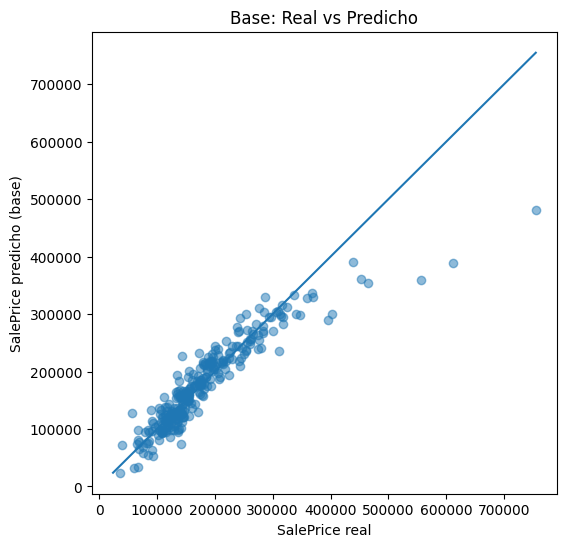

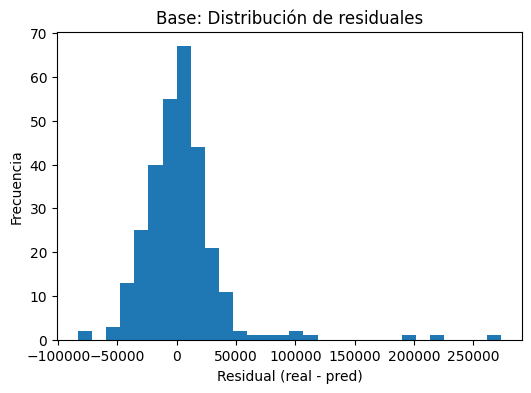

In [ ]:
# Scatter real vs pred
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_base, alpha=0.5)
min_v = min(y_test.min(), y_pred_base.min())
max_v = max(y_test.max(), y_pred_base.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.xlabel("SalePrice real")
plt.ylabel("SalePrice predicho (base)")
plt.title("Base: Real vs Predicho")
plt.show()

# Residuales
res_base = y_test - y_pred_base
plt.figure(figsize=(6,4))
plt.hist(res_base, bins=30)
plt.xlabel("Residual (real - pred)")
plt.ylabel("Frecuencia")
plt.title("Base: Distribución de residuales")
plt.show()

## Sección 8 — Tuning con modelo más flexible: RandomForestRegressor + RandomizedSearchCV

Qué hacemos:
- Entrenamos un modelo más potente para capturar relaciones no lineales:
  - `RandomForestRegressor`.
- Definimos hiperparámetros relevantes:
  - `n_estimators`: cantidad de árboles (más árboles suele estabilizar).
  - `max_depth`: controla complejidad (previene overfitting).
  - `min_samples_split` y `min_samples_leaf`: regularización.
  - `max_features`: controla diversidad de árboles.

Por qué tuning aquí sí importa:
- En RandomForest, los hiperparámetros cambian significativamente el equilibrio bias/varianza.

Qué obtenemos:
- Mejor combinación encontrada según una métrica de error.
- Un modelo tuned comparable contra Ridge base.

In [ ]:
rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

param_dist = {
    "model__n_estimators": [300, 600, 900, 1200],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5, None],
}

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=20,  
    scoring="neg_root_mean_squared_error",  
    cv=3,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Ejecutando RandomizedSearchCV para RandomForestRegressor...")
search.fit(X_train, y_train)

print("\nMejores hiperparámetros:")
print(search.best_params_)
print("Mejor score CV (neg RMSE):", search.best_score_)

Ejecutando RandomizedSearchCV para RandomForestRegressor...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros:
{'model__n_estimators': 900, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
Mejor score CV (neg RMSE): -28890.82536894253


## Sección 9 — Evaluación del mejor modelo tuned

Qué hacemos:
- Evaluamos el mejor modelo (`best_estimator_`) en el mismo test.
- Calculamos las mismas métricas:
  - RMSE, MAE, R²
- Repetimos visualizaciones para comparar comportamiento del error.

Qué obtenemos:
- Resultados “después del tuning”.
- Insumo directo para la comparación y conclusiones.

In [57]:
best_pipe = search.best_estimator_

y_pred_tuned = best_pipe.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned   = r2_score(y_test, y_pred_tuned)

print("=== MODELO TUNED (RandomForest) ===")
print(f"RMSE: {rmse_tuned:,.2f}")
print(f"MAE : {mae_tuned:,.2f}")
print(f"R²  : {r2_tuned:.4f}")


=== MODELO TUNED (RandomForest) ===
RMSE: 28,435.15
MAE : 16,969.01
R²  : 0.8946


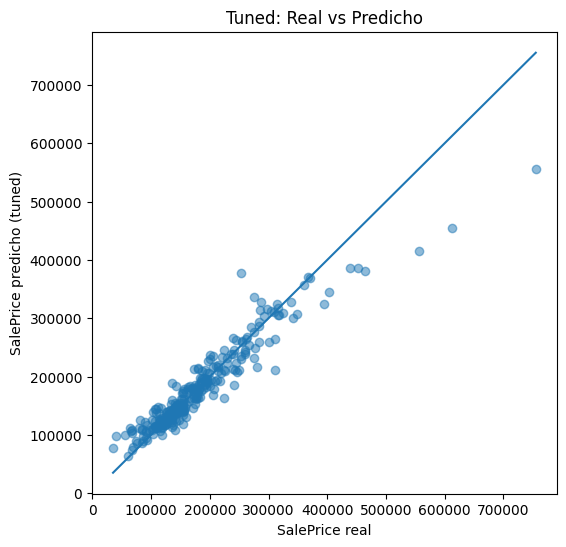

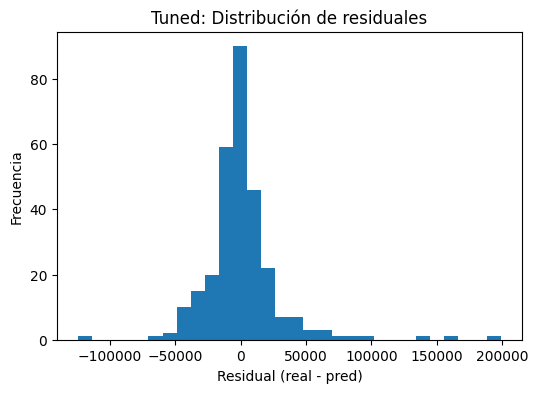

In [58]:
# Scatter real vs pred (tuned)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_tuned, alpha=0.5)
min_v = min(y_test.min(), y_pred_tuned.min())
max_v = max(y_test.max(), y_pred_tuned.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.xlabel("SalePrice real")
plt.ylabel("SalePrice predicho (tuned)")
plt.title("Tuned: Real vs Predicho")
plt.show()

# Residuales (tuned)
res_tuned = y_test - y_pred_tuned
plt.figure(figsize=(6,4))
plt.hist(res_tuned, bins=30)
plt.xlabel("Residual (real - pred)")
plt.ylabel("Frecuencia")
plt.title("Tuned: Distribución de residuales")
plt.show()

## Sección 10 — Comparación final (antes vs después)

Qué hacemos:
- Consolidamos métricas de base y tuned en una tabla.
- Esta tabla cumple el requisito principal del entregable: “comparar antes vs después del tuning”.

Cómo interpretar:
- En regresión, **menor RMSE/MAE es mejor**.
- Mayor R² es mejor (pero RMSE/MAE suelen ser más importantes para conclusiones).

Qué obtenemos:
- Tabla lista para pegar en el apartado de resultados del notebook.

In [59]:
df_compare_reg = pd.DataFrame([
    {"Modelo": "Base (Ridge)", "RMSE": rmse_base, "MAE": mae_base, "R2": r2_base},
    {"Modelo": "Tuned (RandomForest)", "RMSE": rmse_tuned, "MAE": mae_tuned, "R2": r2_tuned},
])
df_compare_reg

,Modelo,RMSE,MAE,R2
0,Base (Ridge),34564.010346,20576.877350,0.844248
1,Tuned (RandomForest),28435.152954,16969.013298,0.894586


## Sección 11 — Conclusiones (plantilla lista para llenar con tus números)

1) Resultado cuantitativo:
- “El tuning redujo RMSE de ___ a ___ y MAE de ___ a ___; además R² cambió de ___ a ___.”

2) Interpretación técnica:
- Si el tuned mejora: “RandomForest captura relaciones no lineales y efectos de interacción entre variables que Ridge no modela.”
- Si el tuned no mejora: “Puede deberse a que el preprocesamiento/representación (one-hot) + Ridge ya era suficientemente fuerte, o a que el espacio de búsqueda fue limitado.”

3) Lectura de hiperparámetros:
- Menciona los mejores (`n_estimators`, `max_depth`, `min_samples_leaf`, etc.) e interpreta:
  - profundidad limitada = controla overfitting,
  - más árboles = reduce varianza,
  - hojas mínimas más grandes = regulariza.

4) Recomendación de mejora (1–2 líneas):
- “Aumentar `n_iter`, probar GradientBoosting/HistGradientBoosting o XGBoost, y/o predecir `log(SalePrice)` para estabilizar varianza (si el profesor lo permite).”